# فاز سوم — Consensus، پروفایل، توضیح‌پذیری و افزونه‌ها

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
json.loads((ROOT / 'artifacts/phase3_run_summary.json').read_text())

{'phase': 3,
 'status': 'completed',
 'elapsed_seconds': 112.45070699998178,
 'consensus_k': 2,
 'candidate_algorithms': ['kmeans',
  'agglomerative_ward',
  'gmm_full_k3',
  'spectral_k3'],
 'validation_accuracy': 0.964,
 'explanation_tree_validation_accuracy': 0.9893375982940157,
 'explanation_tree_training_accuracy': 0.9882045216000533,
 'shap_status': 'completed',
 'cluster_sizes': {'0': 45969, '1': 14054},
 'bonus_status': 'completed',
 'bonus_points_targeted': 15}

In [2]:
pd.read_csv(ROOT / 'reports/tables/phase3_cluster_profiles.csv')

,cluster,profile_name,respondents,share_pct,ExperienceConsensus_median,TechnologyBreadth_median,YearsCodeNumeric_median,YearsCodeProNumeric_median,WorkExpNumeric_median,ConvertedCompYearly_median,DevType_mode,EdLevel_mode,Employment_mode,RemoteWork_mode,AISelect_mode,Country_mode
0,0,Focused-stack practitioners,45969,76.585642,8.0,14.0,11.0,8.0,10.0,65514.0,"Developer, full-stack","Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Employed, full-time","Hybrid (some remote, some in-person)",Yes,United States of America
1,1,Broad-stack polyglots,14054,23.414358,7.5,32.0,10.0,6.0,8.0,64444.0,"Developer, full-stack","Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Employed, full-time","Hybrid (some remote, some in-person)",Yes,United States of America


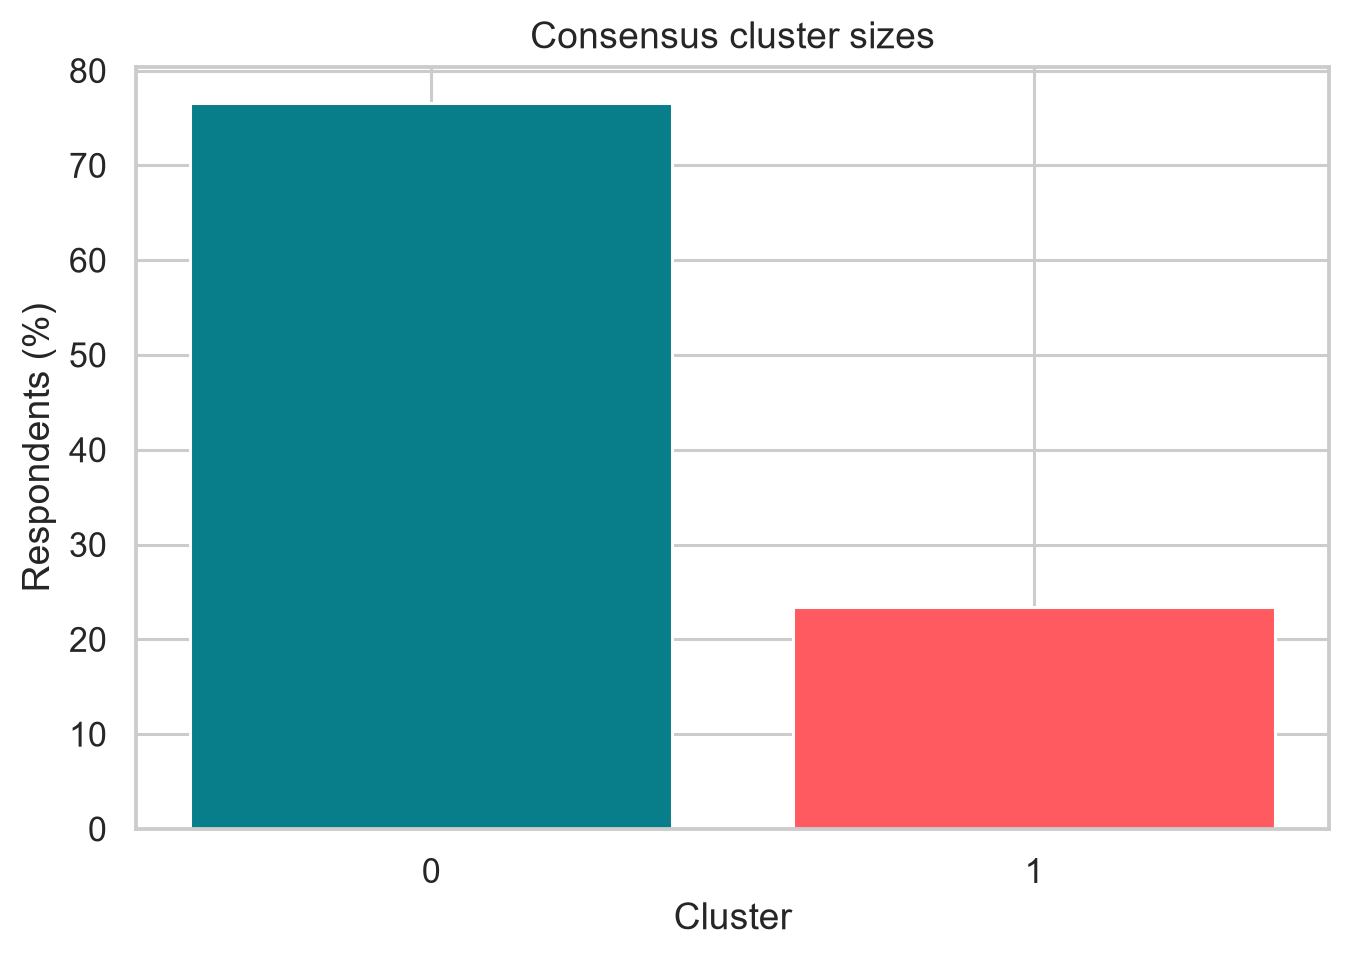

In [3]:
display(Image(filename=ROOT / 'reports/figures/phase3_cluster_sizes.png', width=700))

In [4]:
pd.read_csv(ROOT / 'reports/tables/phase3_cluster_top_technologies.csv').groupby('cluster').head(15)

,cluster,domain,rank,technology,respondents,pct_cluster
0,0,Language,1,JavaScript,26120,56.820901
1,0,Language,2,HTML/CSS,21857,47.547260
2,0,Language,3,SQL,21090,45.878744
3,0,Language,4,Python,20045,43.605473
4,0,Language,5,TypeScript,15021,32.676369
5,0,Language,6,Bash/Shell (all shells),12585,27.377145
6,0,Language,7,Java,11751,25.562879
7,0,Language,8,C#,11087,24.118428
8,0,Database,1,PostgreSQL,16602,36.115643
9,0,Database,2,MySQL,13308,28.949945


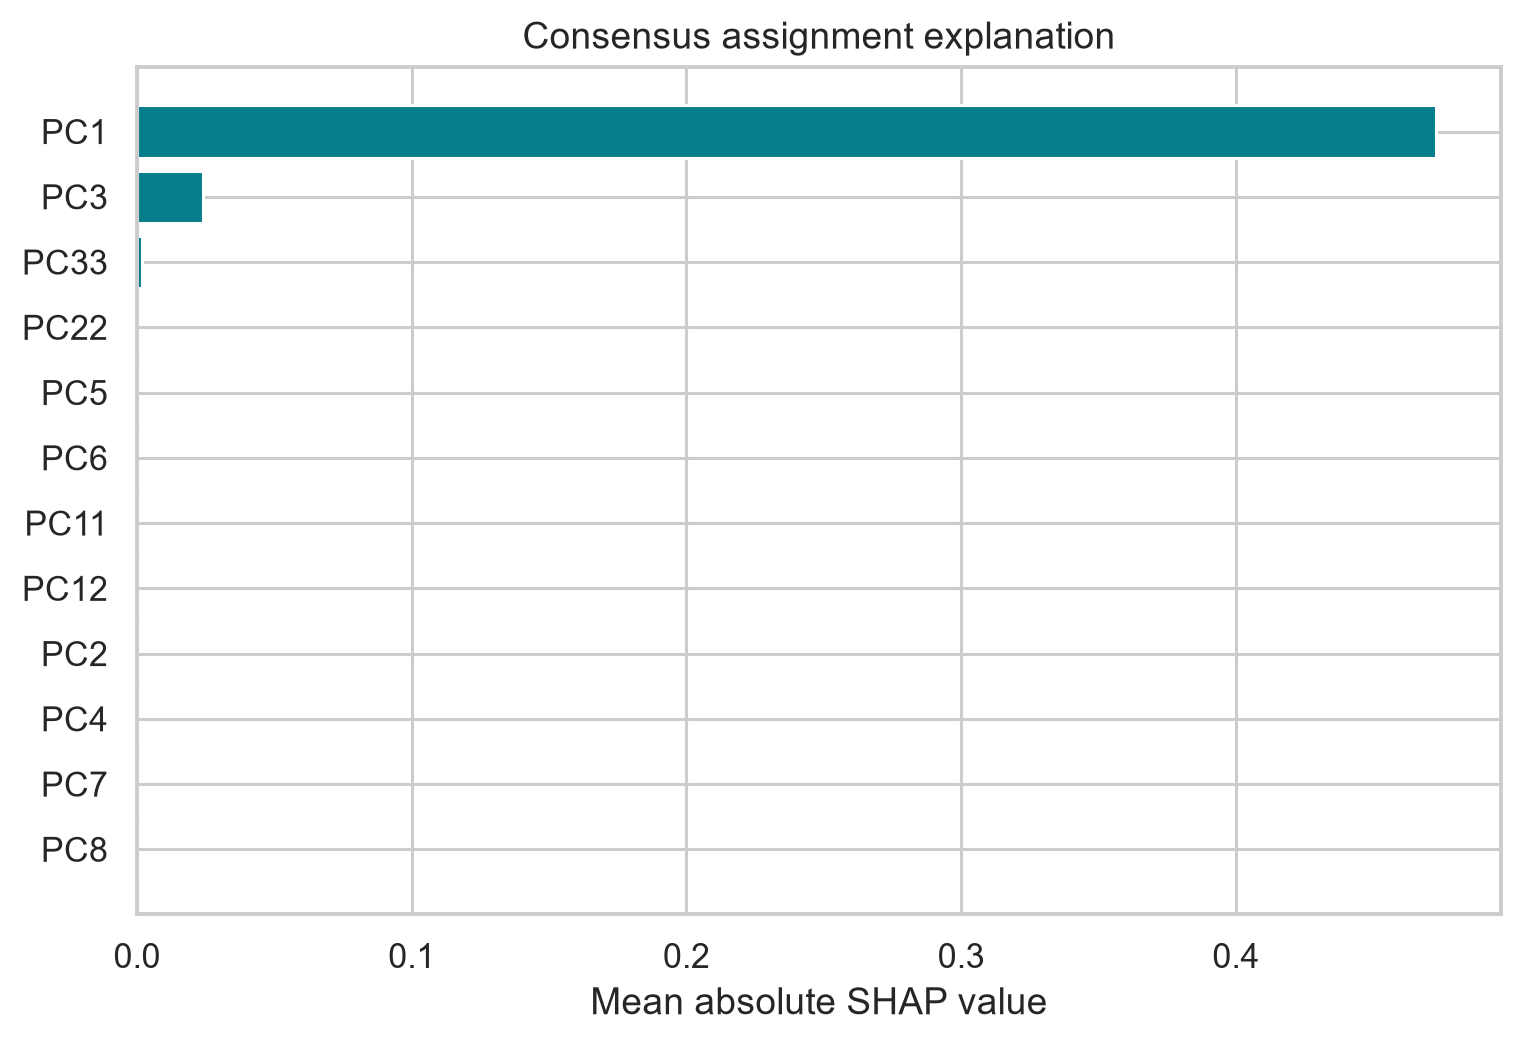

In [5]:
display(Image(filename=ROOT / 'reports/figures/phase3_shap_importance.png', width=750))

In [6]:
pd.read_csv(ROOT / 'reports/tables/phase3_downstream_compensation.csv')

,model,cluster,test_rows,mae_log,global_mae_same_rows
0,global,all,5847,0.707918,NaN
1,cluster_conditional,0,4429,0.709676,0.697647
2,cluster_conditional,1,1418,0.745895,0.740002


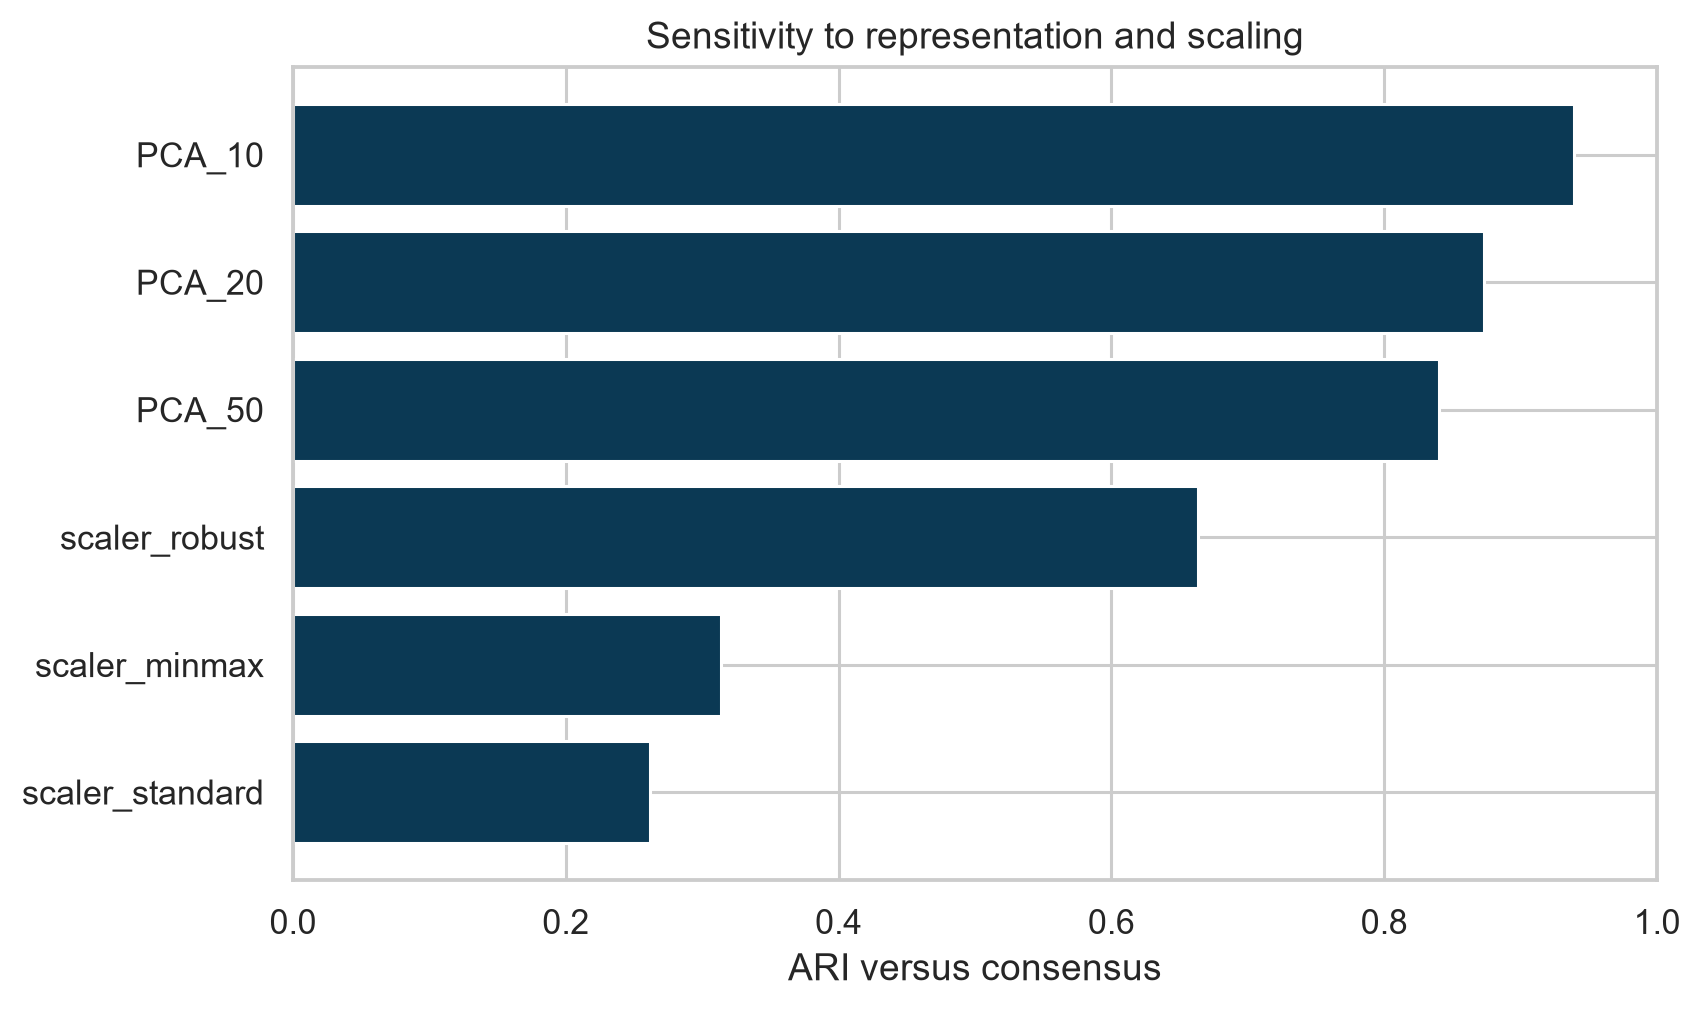

In [7]:
display(Image(filename=ROOT / 'reports/figures/phase3_sensitivity.png', width=750))

## هدف امتیاز افزوده: ۱۵ امتیاز

In [8]:
json.loads((ROOT / 'artifacts/bonus_summary.json').read_text())

{'status': 'completed',
 'created_at_utc': '2026-07-15T22:19:46.224434+00:00',
 'points_targeted': 15,
 'extensions': {'second_advanced_track_nmf': 5,
  'bootstrap_ci_and_permutation_testing': 3,
  'stability_across_meaningful_splits': 4,
  'interactive_3d_umap': 3},
 'nmf': {'selected_components': 4,
  'technology_cosine_silhouette': 0.09783113747835159,
  'ari_vs_consensus': -0.008218139723900113,
  'nmi_vs_consensus': 0.01878783586731463,
  'minimum_cluster_fraction': 0.1723339386568482,
  'model_sha256': '0e39635edc1a368dfa21caca6065b80a8237ad9c58cac569837f2e22b67b844b'},
 'significance': {'best_method': 'agglomerative_ward',
  'runner_up': 'consensus',
  'mean_silhouette_difference': 0.01820589229464531,
  'permutation_pvalue': 0.0001999600079984003,
  'bootstrap_repeats': 200,
  'permutation_repeats': 5000,
  'sample_size': 1200},
 'split_stability': {'stratification': 'ExperienceConsensus median split',
  'threshold': 8.0,
  'split_rows': [31836, 28187],
  'mean_top20_technology

In [9]:
pd.read_csv(ROOT / 'reports/tables/bonus_nmf_scores.csv')

,components,technology_cosine_silhouette,latent_silhouette,minimum_cluster_fraction,reconstruction_error_per_row,ari_vs_consensus,nmi_vs_consensus,iterations,valid,selected
0,2,0.070138,0.298160,0.308798,0.015053,-0.043132,0.069863,1,True,False
1,3,0.054777,0.173595,0.169902,0.015593,-0.024787,0.067686,1,True,False
2,4,0.097831,0.337592,0.172334,0.013979,-0.008218,0.018788,4,True,True
3,5,0.090359,0.300602,0.154391,0.013800,-0.005829,0.023428,4,True,False
4,6,0.083278,0.269473,0.110591,0.013650,0.002529,0.020323,5,True,False


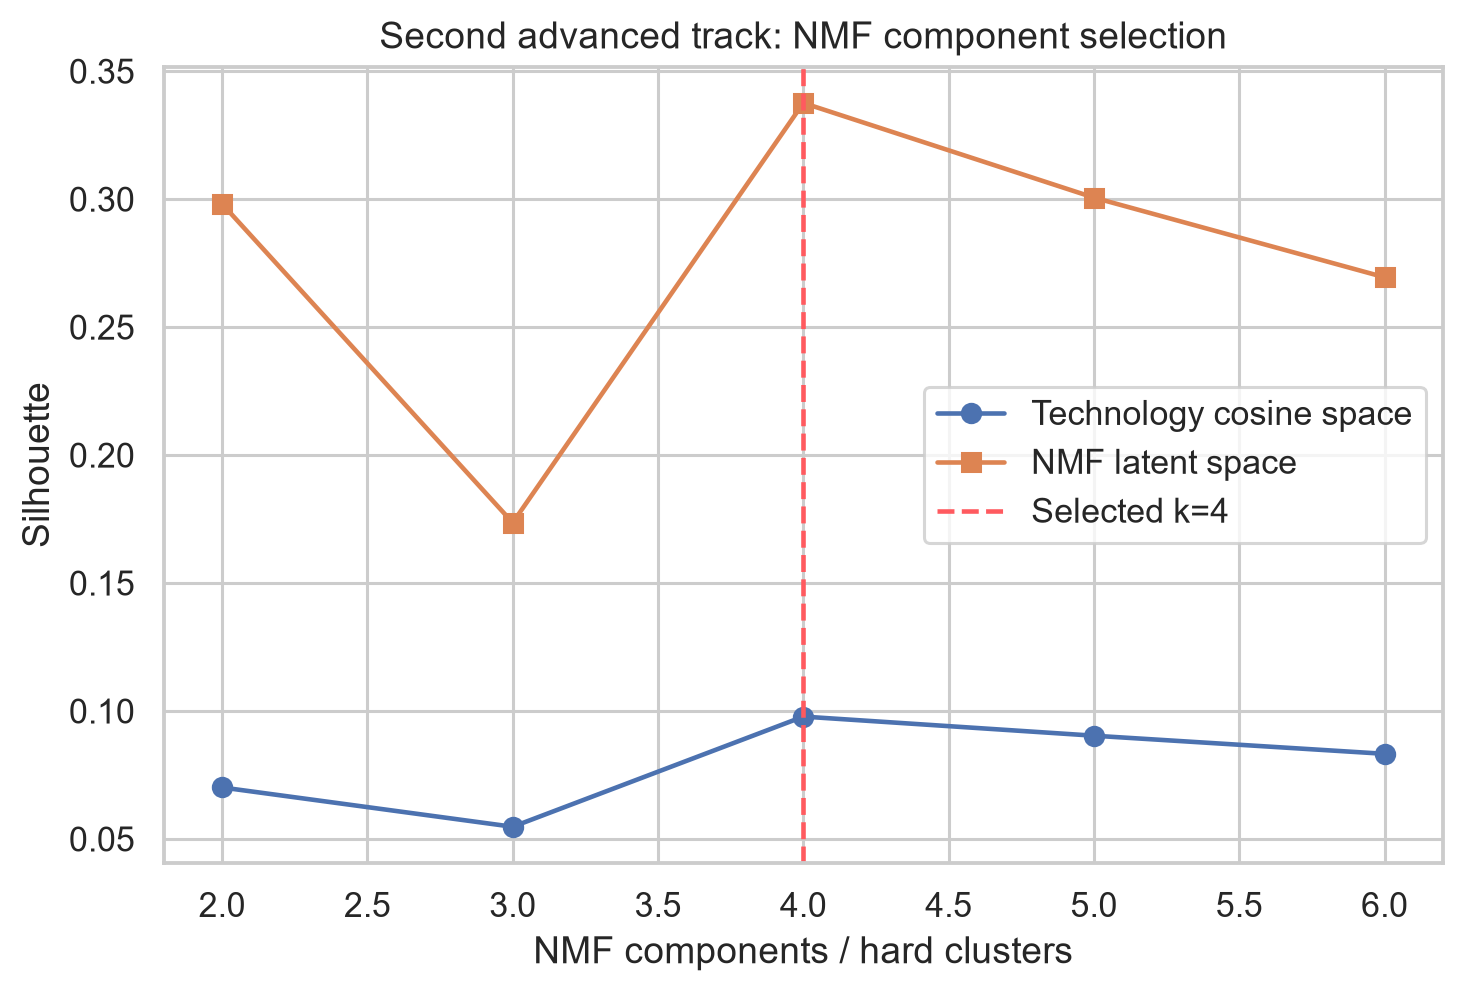

In [10]:
display(Image(filename=ROOT / 'reports/figures/bonus_nmf_comparison.png', width=750))

In [11]:
pd.read_csv(ROOT / 'reports/tables/bonus_metric_confidence_intervals.csv')

,method,metric,estimate,ci_lower,ci_upper,confidence,bootstrap_repeats,sample_size,reference_is_not_ground_truth
0,consensus,silhouette,0.199584,0.192774,0.207059,0.95,200,1200,False
1,consensus,calinski_harabasz_per_row,0.141584,0.125169,0.158791,0.95,200,1200,False
2,consensus,davies_bouldin,2.307056,2.180403,2.428058,0.95,200,1200,False
3,consensus,ari_vs_consensus,1.000000,1.000000,1.000000,0.95,200,1200,True
4,consensus,nmi_vs_consensus,1.000000,1.000000,1.000000,0.95,200,1200,True
5,kmeans,silhouette,0.197058,0.189349,0.203622,0.95,200,1200,False
6,kmeans,calinski_harabasz_per_row,0.144198,0.125392,0.160719,0.95,200,1200,False
7,kmeans,davies_bouldin,2.308423,2.179969,2.462062,0.95,200,1200,False
8,kmeans,ari_vs_consensus,0.942330,0.911130,0.966948,0.95,200,1200,True
9,kmeans,nmi_vs_consensus,0.877734,0.824059,0.920641,0.95,200,1200,True


In [12]:
pd.read_csv(ROOT / 'reports/tables/bonus_permutation_tests.csv')

,comparison,first_method,second_method,mean_silhouette_difference,difference_ci_lower,difference_ci_upper,permutation_pvalue_two_sided,permutation_repeats,sample_size
0,best_vs_runner_up,agglomerative_ward,consensus,0.018206,0.014475,0.021512,0.0002,5000,1200


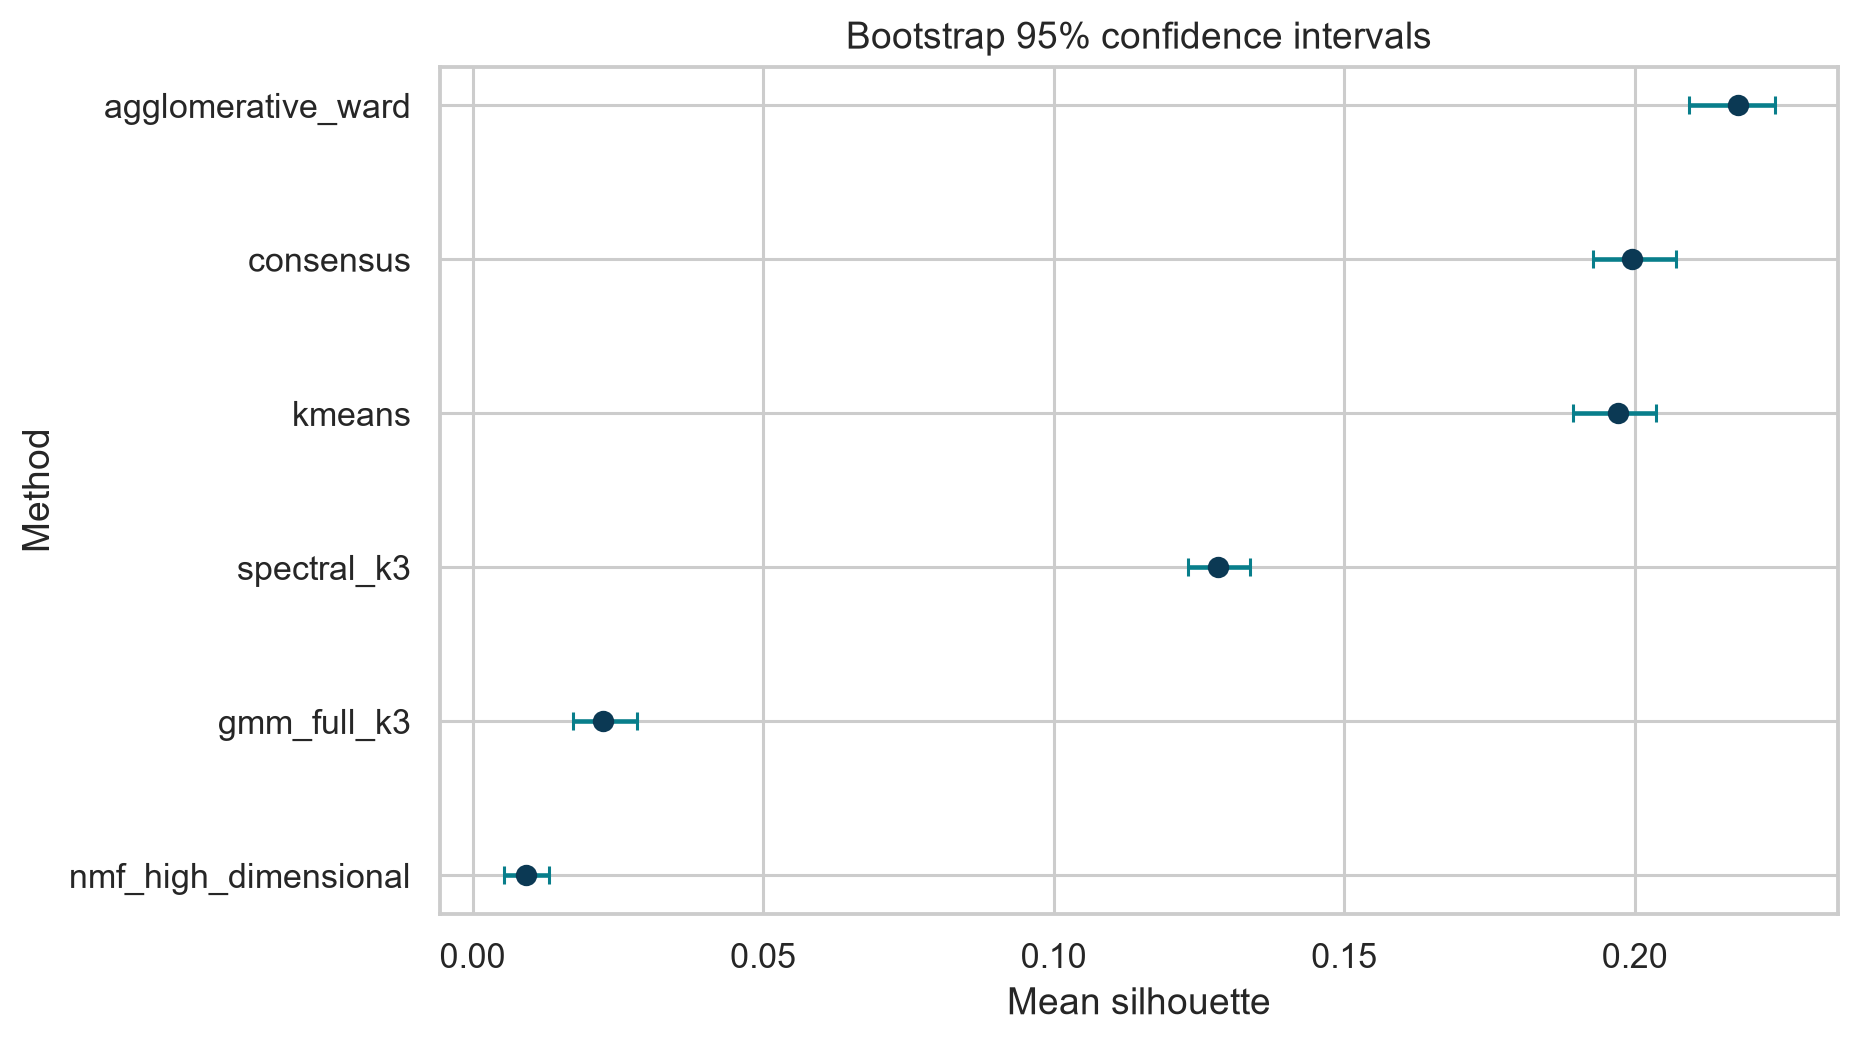

In [13]:
display(Image(filename=ROOT / 'reports/figures/bonus_silhouette_confidence_intervals.png', width=800))

In [14]:
pd.read_csv(ROOT / 'reports/tables/bonus_split_stability.csv')

,split_a,cluster_a,split_b,cluster_b,rows_a,rows_b,prototype_distance_pca,top20_technology_jaccard,shared_top_technologies
0,experience_le_8,0,experience_gt_8,1,13187,5516,3.670331,0.600000,Amazon Web Services (AWS); Bash/Shell (all she...
1,experience_le_8,1,experience_gt_8,0,18649,22671,2.684687,0.666667,Amazon Web Services (AWS); Bash/Shell (all she...


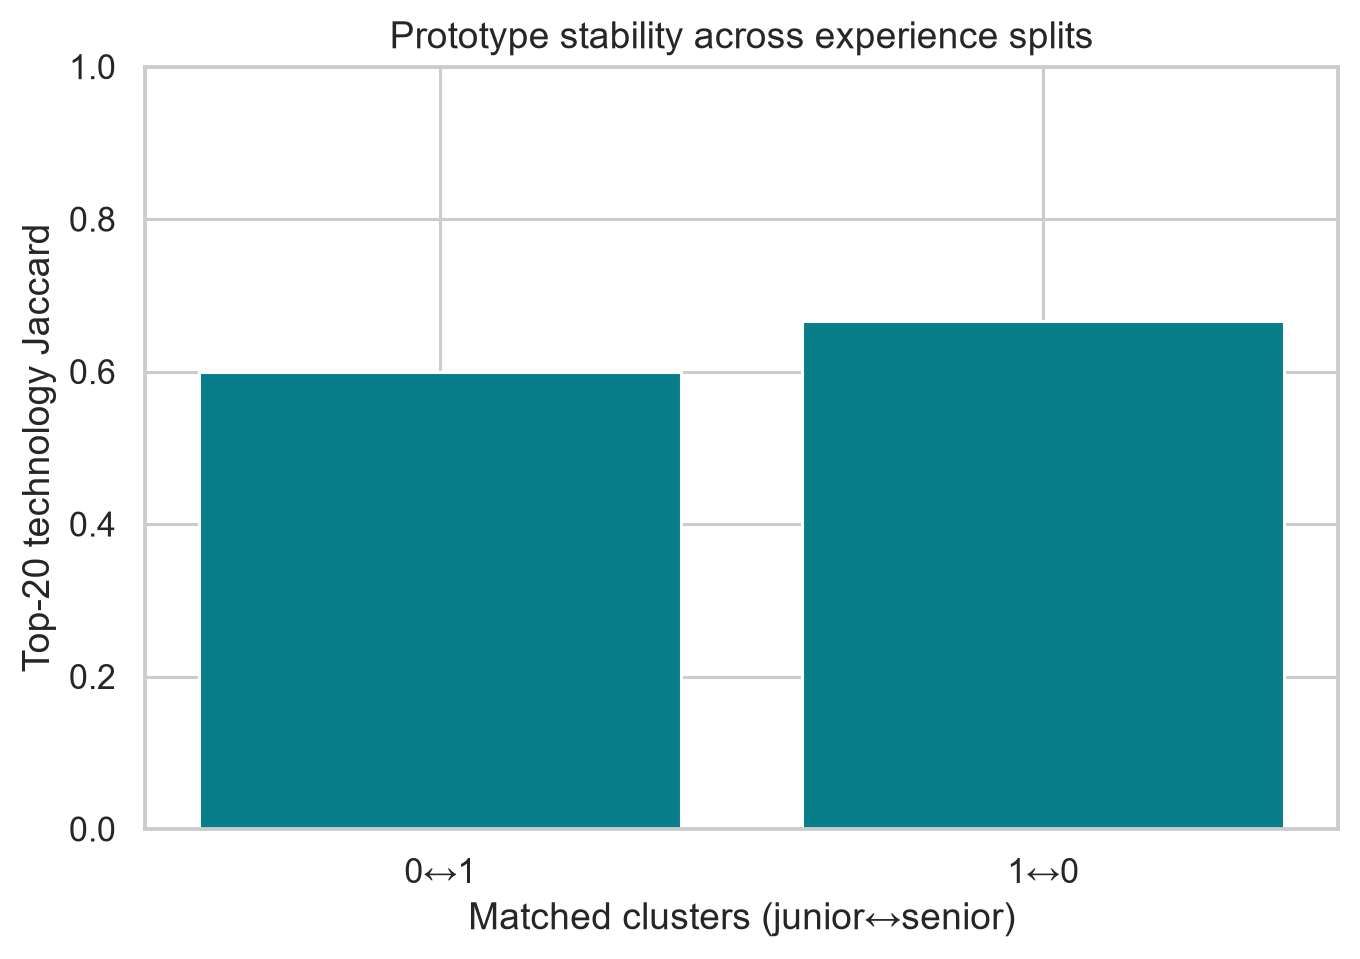

In [15]:
display(Image(filename=ROOT / 'reports/figures/bonus_split_stability.png', width=700))

NMF چهار مؤلفه فناوری را برگزید، اما توافق آن با consensus ناچیز بود؛ بنابراین ساختار فناوری‌محور مکمل است نه تأیید همان دو پروفایل. آزمون permutation نیز برتری silhouette روش Ward بر consensus را نشان داد. پایداری واژگان فناوری میان دو نیمه تجربه متوسط است و نمایش UMAP سه‌بعدی فقط ابزار اکتشافی است.